## Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

## Load Prepared Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

## Verify Dataset

In [3]:
print("Training Features :", X_train.shape)
print("Training Labels   :", y_train.shape)

print()

print("Testing Features  :", X_test.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (453204, 33)
Training Labels   : (453204,)

Testing Features  : (56746, 33)
Testing Labels    : (56746,)


## Train Decision Tree

In [4]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Make Predictions

In [5]:
y_pred = decision_tree.predict(X_test)

y_prob = decision_tree.predict_proba(X_test)[:, 1]

## Accuracy

In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9977


## Precision

In [7]:
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.3975


## Recall

In [8]:
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.6737


## F1 Score

In [9]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.5000


## Classification Report

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.40      0.67      0.50        95

    accuracy                           1.00     56746
   macro avg       0.70      0.84      0.75     56746
weighted avg       1.00      1.00      1.00     56746



## Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56554    97]
 [   31    64]]


## ROC-AUC

In [12]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score : {roc_auc:.4f}")

ROC-AUC Score : 0.8360


## ROC Curve

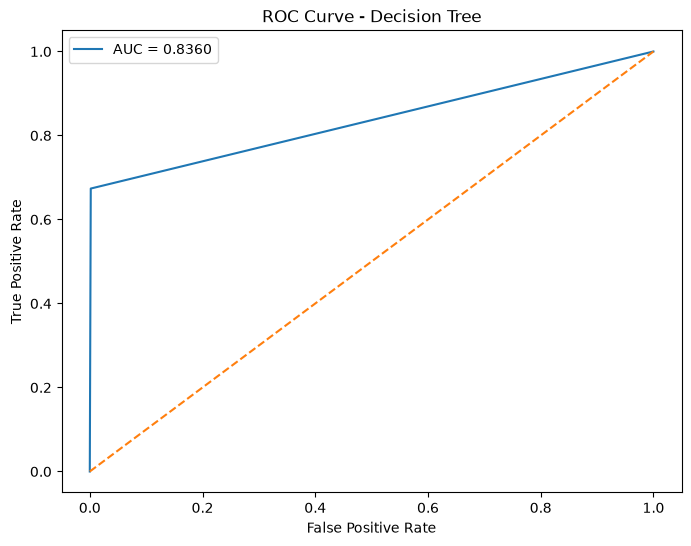

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

## Save the Model

In [14]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(decision_tree, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

### Verifiy

In [15]:
os.listdir("../models")

['decision_tree.pkl', 'logistic_regression.pkl']

## Final Observation

- Loaded the prepared training and testing datasets.
- Trained a Decision Tree classifier.
- Generated predictions on the unseen test data.
- Evaluated the model using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, Classification Report, and ROC-AUC.
- Plotted the ROC Curve.
- Saved the trained Decision Tree model for future use.